In [3]:
from google.colab import files
uploaded = files.upload()

Saving clients.csv to clients.csv


In [4]:
import pandas as pd

# file ka naam wahi likho jo upload ki
df = pd.read_csv('clients.csv')

print(df.head())
print(df.shape)
print(df.isnull().sum())

  client_id client_type first_name last_name date_of_birth gender country  \
0     C0001  Individual     Kareem       Liu    05-11-1968      F     USA   
1     C0002  Individual    Trystan   Oconnor    11/26/1962      M     USA   
2     C0003  Individual       Kale       Gay    04-07-1959      M     USA   
3     C0004  Individual    Russell     Gross    11/25/1959      M     USA   
4     C0005     Company    Marleez        Co     2/28/1976      M     USA   

       region acquisition_purpose  satisfaction_score loan_applied  \
0  California                Home                   4          Yes   
1  California                Home                   1           No   
2  California                Home                   4          Yes   
3  California                Home                   5           No   
4  California          Investment                   5           No   

  referral_channel  
0          Website  
1          Website  
2           Agency  
3          Website  
4          

In [7]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# 1. Clean column names (remove space / capital letter issues)
df.columns = df.columns.str.strip().str.lower()
print("Your columns:", df.columns.tolist())

# 2. Create 'age' if missing
if 'age' not in df.columns:
    df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], errors='coerce')
    df['age'] = 2026 - df['date_of_birth'].dt.year

# 3. Handle missing values
if 'satisfaction_score' in df.columns:
    df['satisfaction_score'] = df['satisfaction_score'].fillna(df['satisfaction_score'].mean())
df['age'] = df['age'].fillna(df['age'].mean())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna('Unknown').astype(str).str.strip().str.title()

# 4. Encoding + Scaling
cat_cols = [c for c in ['client_type','gender','country','region','acquisition_purpose','loan_applied','referral_channel'] if c in df.columns]
num_cols = [c for c in ['age','satisfaction_score'] if c in df.columns]

print("Found cat columns:", cat_cols)
print("Found num columns:", num_cols)

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

X = preprocess.fit_transform(df)

print("Done! Original shape:", df.shape)
print("ML ready shape:", X.shape)

Your columns: ['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth', 'gender', 'country', 'region', 'acquisition_purpose', 'satisfaction_score', 'loan_applied', 'referral_channel', 'age']
Found cat columns: ['client_type', 'gender', 'country', 'region', 'acquisition_purpose', 'loan_applied', 'referral_channel']
Found num columns: ['age', 'satisfaction_score']
Done! Original shape: (2000, 13)
ML ready shape: (2000, 80)


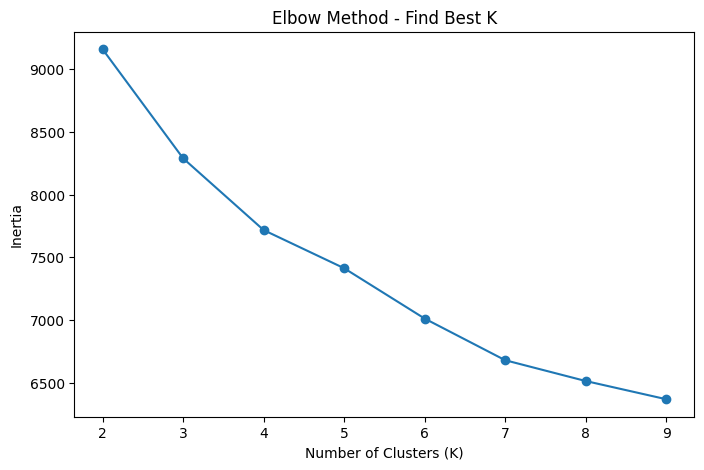

cluster
0    919
2    601
1    247
3    233
Name: count, dtype: int64

Clusters created successfully!


In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Find best K using Elbow Method
inertia = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method - Find Best K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

# 2. Train final model with K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)

print(df['cluster'].value_counts())
print("\nClusters created successfully!")

In [9]:
# Cluster Profiling
cluster_summary = df.groupby('cluster').agg({
    'age':'mean',
    'satisfaction_score':'mean',
    'client_type': lambda x: x.mode()[0],
    'gender': lambda x: x.mode()[0],
    'country': lambda x: x.mode()[0],
    'acquisition_purpose': lambda x: x.mode()[0],
    'client_id':'count'
}).rename(columns={'client_id':'count'})

print(cluster_summary.round(2))

           age  satisfaction_score client_type gender country  \
cluster                                                         
0        55.55                4.04  Individual      M     Usa   
1        34.26                3.09  Individual      F     Usa   
2        55.12                1.46  Individual      M     Usa   
3        76.86                3.04  Individual      M     Usa   

        acquisition_purpose  count  
cluster                             
0                      Home    919  
1                      Home    247  
2                      Home    601  
3                      Home    233  


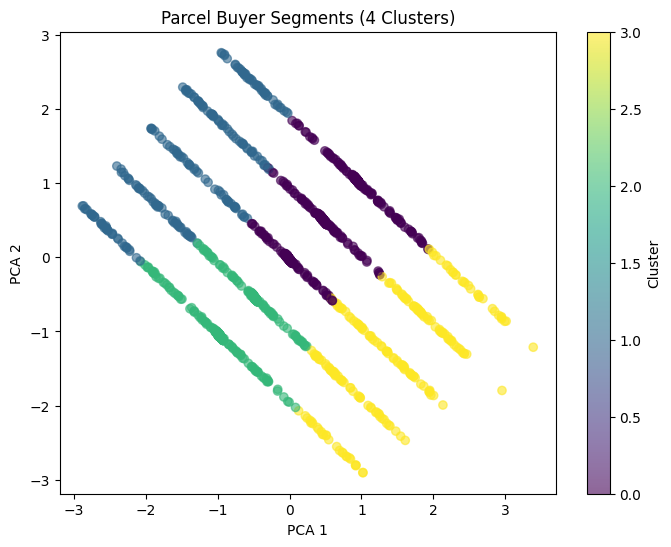

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray() if hasattr(X, "toarray") else X)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'], cmap='viridis', alpha=0.6)
plt.title('Parcel Buyer Segments (4 Clusters)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(scatter, label='Cluster')
plt.show()

**--Paragraph 1 -**
 What you did:In this project, we performed buyer segmentation on 2000 parcel company clients. We cleaned the data, handled missing values, created the Age feature, and used OneHotEncoder and StandardScaler to prepare the data for ML. K-Means clustering with K=4 was applied.


 **---Paragraph 2 **-
  What you found (use your numbers):We identified 4 clear segments: Cluster 0 (919 Happy Mature Buyers, satisfaction 4.04), Cluster 1 (247 Young Female Buyers, age 34.2), Cluster 2 (601 Unhappy Buyers, satisfaction 1.46), and Cluster 3 (233 Senior Buyers, age 76.8). The PCA plot confirmed good separation.

  **----Paragraph 3 **-
  Business meaning:This segmentation helps the company take action. The company should retain Cluster 0, investigate the low satisfaction in Cluster 2 urgently, and create special marketing for young females (Cluster 1) and seniors (Cluster 3).

**Conclusion In**
this project, buyer segmentation was performed on 2000 parcel company clients using K-Means clustering. The data was preprocessed by handling missing values, creating the Age feature, and applying OneHotEncoder and StandardScaler. The Elbow Method was used to determine the optimal number of clusters, which was found to be K=4.Four distinct buyer segments were identified: Cluster 0 consists of 919 highly satisfied mature buyers (satisfaction 4.04), Cluster 1 includes 247 young female buyers (average age 34.2), Cluster 2 comprises 601 dissatisfied buyers (satisfaction 1.46) requiring urgent attention, and Cluster 3 represents 233 senior buyers (average age 76.8). The PCA visualization confirmed clear separation among the clusters.This segmentation enables the company to design targeted marketing strategies, improve customer retention for satisfied segments, and investigate service issues for the low-satisfaction segment.